TỐI ƯU MÔ HÌNH

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("zillow_final.csv")


In [2]:
len(df)

4468

In [3]:
df.nlargest(
    5,
    "price"
)[[ "price", "lot_living"]]

,price,lot_living
29,400000000.0,4.892348
18,170000000.0,12.745603
15,135000000.0,5.253336
100,125000000.0,1.912680
77,95000000.0,7.710194


In [4]:
upper = df["price"].quantile(0.95)

df = df[df["price"] <= upper]

In [5]:
len(df)

4251

In [6]:
X = df.drop(columns = ["price"])

y = df["price"]


ĐỂ KẾT QUẢ KHÔNG PHỤ THUỘC VÀO 1 LẦN CHIA DỮ LIỆU DÙNG Cross Validation.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)


In [8]:
# Mô hình 2 Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42
)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print(scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

[0.81156403 0.84770523 0.84698233 0.81975208 0.81847952]
Mean R2: 0.8288966365619848
Std: 0.01531935804563885


KIỂM TRA GIÁ NHÀ

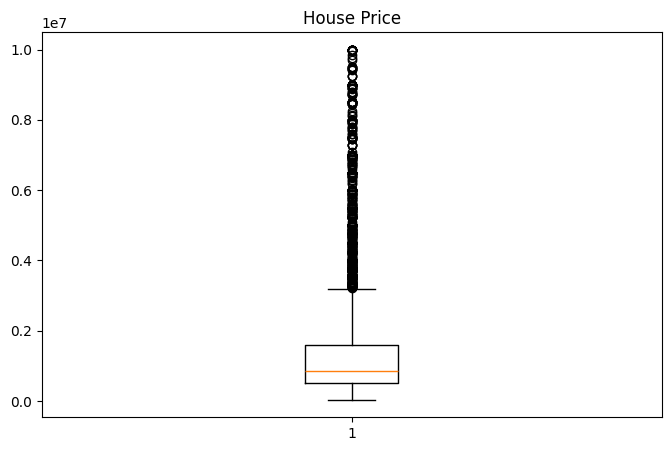

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(y)
plt.title("House Price")
plt.show()

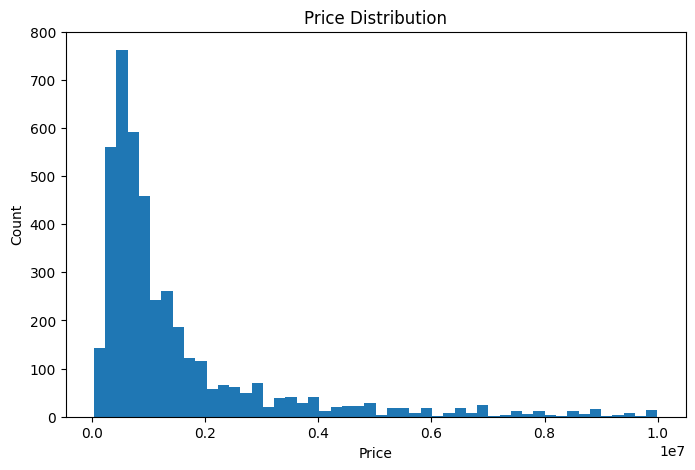

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y, bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

KIỂM TRA OVERFITTING

In [15]:
from sklearn.metrics import r2_score

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train:", r2_score(y_train, train_pred))
print("Test :", r2_score(y_test, test_pred))

Train: 0.9621442868992878
Test : 0.812823478865236


 ĐÙNG RandomizedSearchCV ĐỂ TÌM PARAMETER TỐI ƯU NHẤT

In [13]:
param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [8, 10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"]
}

In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [8, 10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,              
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose= 2
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
0.8190118883930072


In [21]:
best_rf = random_search.best_estimator_

pred = best_rf.predict(X_test)

print(r2_score(y_test, pred))

0.7967878640144614
